Dimensiones: (125, 147, 128)
Voxel size: [0.75000006 0.75       0.75      ]
Corte guía: 83
Rango evaluado: 65 a 101


C:\Users\meime\AppData\Local\Temp\ipykernel_31004\4084166069.py:259: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  mask = remove_small_objects(mask, min_size=500)
C:\Users\meime\AppData\Local\Temp\ipykernel_31004\4084166069.py:276: FutureWarning: `binary_erosion` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.erosion` instead. Note the pixel shift by 1 for even-sized footprints (see docstring notes).
  mask_interno = binary_erosion(mask_cerebro, disk(erosion_borde))
C:\Users\meime\AppData\Local\Temp\ipykernel_31004\4084166069.py:328: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0

Corte 100 sin 2 ventrículos válidos. Fallo 1/1
Se detuvo hacia cortes mayores en 100

---- RESULTADO 3D ----
Volumen ventricular total: 3613.3597 mm³
Volumen ventricular total: 3.6134 mL

---- MEDICIONES POR CORTE Y VENTRÍCULO ----


,Corte,Ventrículo,Área (mm²),Ancho atrial (mm),Orientación
0,65,1,102.375008,9.750000,vertical
1,65,2,68.625005,6.000000,vertical
2,66,1,100.125008,9.000000,vertical
3,66,2,86.062507,8.250001,horizontal
4,67,1,111.937509,5.250000,vertical
...,...,...,...,...,...
65,97,2,33.750003,5.250000,horizontal
66,98,1,56.812505,6.000000,vertical
67,98,2,47.250004,6.000000,horizontal
68,99,1,73.125006,6.000000,vertical


interactive(children=(IntSlider(value=83, description='k', max=101, min=65), Output()), _dom_classes=('widget-…

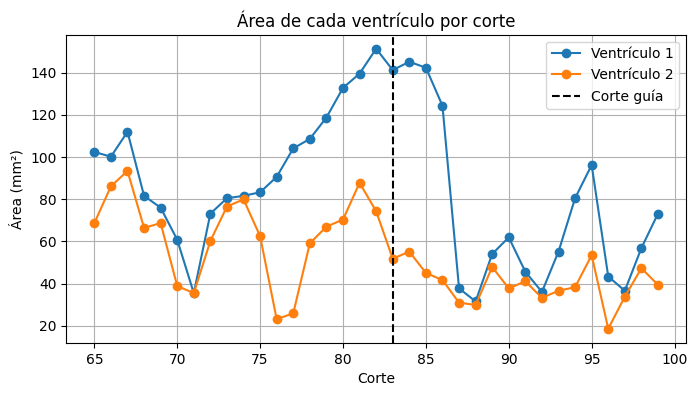


---- CLASIFICACIÓN FINAL ----
Diámetro atrial máximo: 9.7500 mm
Clasificación final: Normal

Resultado guardado en resultado_etapa5.npy


In [5]:
# ===========================
# ETAPA 5: Reconstrucción y análisis volumétrico 3D
# ===========================
# Objetivo:
# Utilizar la máscara obtenida en la Etapa 4 como referencia
# para seguir automáticamente los ventrículos en los cortes
# vecinos del volumen MRI.
#
# Cada corte se segmenta utilizando la posición del corte
# anterior, permitiendo reconstruir el volumen completo de
# los ventrículos y calcular:
#
# - Área por corte
# - Ancho atrial por ventrículo
# - Volumen ventricular total
# - Clasificación final

# Librería para leer archivos NIfTI (.nii)
import nibabel as nib

# Librería para operaciones numéricas y manejo de matrices
import numpy as np

# Librería para visualizar imágenes y gráficas
import matplotlib.pyplot as plt

# Librería para organizar resultados en tablas
import pandas as pd

# Permite crear un slider interactivo para recorrer los cortes
from ipywidgets import interact, IntSlider

# Funciones para filtrado y operaciones binarias
from scipy.ndimage import median_filter, binary_fill_holes

# Umbral automático de Otsu
from skimage.filters import threshold_otsu

# Operaciones morfológicas
# disk: elemento estructurante circular
# dilation: expande una máscara
# opening: elimina ruido pequeño
# closing: rellena pequeñas discontinuidades
# remove_small_objects: elimina objetos pequeños
# binary_erosion: contrae una máscara
from skimage.morphology import (
    disk, dilation, opening, closing,
    remove_small_objects, binary_erosion
)

# label identifica componentes conectadas
# regionprops calcula propiedades geométricas de cada componente
from skimage.measure import label, regionprops

# ===========================
# 1. CARGAR DATOS
# ===========================
# Se carga:
#
# 1. La imagen MRI completa en 3D.
# 2. La máscara obtenida en la Etapa 4, la cual será el
#    punto de partida para seguir los ventrículos en los
#    cortes vecinos.

# Ruta del archivo MRI
filename = r'C:\Users\meime\OneDrive\Documents\Procesamiento imagen\Reto\5187149.nii'

# Cargar resultados de Etapa 4
datos4 = np.load('resultado_etapa4.npy', allow_pickle=True).item()

# Máscara guía que contiene los ventrículos segmentados
mask_guia = datos4['mask_final']

# Tamaño físico del voxel
voxel_size = datos4['voxel_size']

# Leer volumen MRI
img_nib = nib.load(filename)

# Obtener matriz de intensidades
img_data = img_nib.get_fdata()

# Convertir a tipo float para facilitar operaciones
img = img_data.astype(float)

# Algunas imágenes tienen una cuarta dimensión
# (por ejemplo tiempo o canales). Si existe,
# únicamente se utiliza el primer volumen.
if img.ndim == 4:
    img = img[:, :, :, 0]

# Normalizar intensidades entre 0 y 1
img = img / img.max()

# Obtener resolución espacial
dx, dy, dz = voxel_size[:3]

print("Dimensiones:", img.shape)
print("Voxel size:", voxel_size[:3])


# ===========================
# 2. PARÁMETROS
# ===========================
# Estos parámetros controlan el seguimiento de los
# ventrículos a través del volumen.

# Corte donde se encuentra la mejor segmentación
# obtenida previamente.
corte_guia = 83

# Número máximo de cortes hacia adelante y hacia atrás
# que serán analizados.
rango = 18

# Radio de expansión de la ROI.
# Permite buscar el ventrículo cerca de su posición
# anterior sin analizar toda la imagen.
radio_roi = 13

# Percentil utilizado para detectar LCR brillante.
percentil_lcr = 85

# Área mínima permitida para aceptar una componente.
area_min_pix = 12

# Número de píxeles eliminados del borde cerebral.
erosion_borde = 3

# Número máximo de cortes consecutivos donde puede
# fallar la segmentación antes de detener el seguimiento.
max_fallos = 1

# Calcular rango real de cortes.
inicio = max(0, corte_guia - rango)
fin = min(img.shape[2], corte_guia + rango + 1)

print("Corte guía:", corte_guia)
print(f"Rango evaluado: {inicio} a {fin-1}")


# ===========================
# 3. MEDIR ANCHO ATRIAL
# ===========================
# Esta función mide el ancho atrial dentro de una máscara binaria.
# La máscara corresponde a un ventrículo individual.
#
# La idea es:
# 1. Buscar la línea horizontal más larga dentro del ventrículo.
# 2. Buscar la línea vertical más larga dentro del ventrículo.
# 3. Convertir ambas medidas de píxeles a milímetros.
# 4. Elegir la medida más corta como ancho atrial.
#
# Esto se hace porque el ventrículo puede ser más largo en una dirección,
# pero clínicamente interesa el diámetro menor o ancho.

def medir_ancho_atrial(mask_objeto, dx, dy):

    # Obtener las coordenadas de todos los píxeles que pertenecen a la máscara.
    coords = np.argwhere(mask_objeto)

    # Si la máscara está vacía, no hay nada que medir.
    if coords.size == 0:
        return 0, None, "sin datos"

    # Inicializar variables para guardar la mejor línea horizontal.
    mejor_h = 0
    linea_h = None

    # Recorrer cada fila donde existe al menos un píxel de la máscara.
    for fila in np.unique(coords[:, 0]):

        # Obtener las columnas ocupadas por la máscara en esa fila.
        cols = coords[coords[:, 0] == fila, 1]

        # Primera y última columna ocupada en esa fila.
        c1, c2 = cols.min(), cols.max()

        # Verificar que todos los píxeles entre c1 y c2 pertenezcan a la máscara.
        # Esto asegura que la línea medida esté completamente dentro del ventrículo.
        if np.all(mask_objeto[fila, c1:c2+1]):

            # Longitud de esa línea en píxeles.
            largo = c2 - c1 + 1

            # Si esta línea es más larga que la anterior, se guarda.
            if largo > mejor_h:
                mejor_h = largo
                linea_h = (c1, fila, c2, fila)

    # Inicializar variables para guardar la mejor línea vertical.
    mejor_v = 0
    linea_v = None

    # Recorrer cada columna donde existe al menos un píxel de la máscara.
    for col in np.unique(coords[:, 1]):

        # Obtener las filas ocupadas por la máscara en esa columna.
        filas = coords[coords[:, 1] == col, 0]

        # Primera y última fila ocupada en esa columna.
        f1, f2 = filas.min(), filas.max()

        # Verificar que todos los píxeles entre f1 y f2 pertenezcan a la máscara.
        if np.all(mask_objeto[f1:f2+1, col]):

            # Longitud de esa línea en píxeles.
            largo = f2 - f1 + 1

            # Si esta línea es más larga que la anterior, se guarda.
            if largo > mejor_v:
                mejor_v = largo
                linea_v = (col, f1, col, f2)

    # Convertir las longitudes de píxeles a milímetros.
    # dx se usa para distancias horizontales.
    # dy se usa para distancias verticales.
    ancho_h_mm = mejor_h * dx
    ancho_v_mm = mejor_v * dy

    # Elegir la orientación más corta como ancho atrial.
    # Además se regresa la línea correspondiente para dibujarla después.
    if ancho_h_mm <= ancho_v_mm:
        return ancho_h_mm, linea_h, "horizontal"
    else:
        return ancho_v_mm, linea_v, "vertical"


# ===========================
# 4. MÁSCARA CEREBRAL
# ===========================
# Estas funciones generan una máscara del cerebro en cada corte.
# Esto sirve para evitar que la segmentación detecte estructuras
# fuera del área cerebral, como fondo o bordes externos.

def crear_mask_cerebro(A):

    # Aplicar filtro de mediana para reducir ruido antes de umbralizar.
    A_filt = median_filter(A, size=3)

    # Calcular un umbral automático con Otsu.
    # Si Otsu falla, se regresa una máscara vacía.
    try:
        umbral = threshold_otsu(A_filt)
    except:
        return np.zeros_like(A, dtype=bool)

    # Crear máscara inicial del cerebro.
    # Se usa la mitad del umbral de Otsu para no perder tejido.
    mask = A_filt > umbral * 0.5

    # Cerrar huecos pequeños y unir regiones cercanas.
    mask = closing(mask, disk(4))

    # Rellenar huecos internos de la máscara cerebral.
    mask = binary_fill_holes(mask)

    # Eliminar objetos pequeños que no corresponden al cerebro.
    mask = remove_small_objects(mask, min_size=500)

    return mask


def crear_mask_cerebro_interno(A):

    # Crear la máscara cerebral completa.
    mask_cerebro = crear_mask_cerebro(A)

    # Si la máscara está vacía, se regresa igual.
    if np.sum(mask_cerebro) == 0:
        return mask_cerebro

    # Erosionar la máscara cerebral para quitar una franja periférica.
    # Esto evita que el algoritmo detecte bordes externos como ventrículos.
    if erosion_borde > 0:
        mask_interno = binary_erosion(mask_cerebro, disk(erosion_borde))
    else:
        mask_interno = mask_cerebro

    return mask_interno


# ===========================
# 5. SEGMENTAR EN ROI
# ===========================
# Esta función segmenta un posible ventrículo dentro de una región de interés.
#
# En lugar de buscar en toda la imagen, solo busca dentro de la ROI
# generada alrededor del ventrículo del corte anterior.
#
# Esto ayuda a reducir falsas detecciones en otras zonas brillantes.

def segmentar_en_roi(A, roi):

    # Suavizar el corte actual con filtro de mediana.
    A_filt = median_filter(A, size=3)

    # Crear máscara interna del cerebro.
    # La ROI se limitará a esta región para evitar bordes externos.
    mask_cerebro_interno = crear_mask_cerebro_interno(A)

    # Intersectar la ROI con la máscara cerebral interna.
    # Así solo se busca dentro del cerebro y lejos del borde.
    roi = roi & mask_cerebro_interno

    # Extraer intensidades únicamente dentro de la ROI.
    pixeles_roi = A_filt[roi]

    # Si no hay píxeles dentro de la ROI, no se puede segmentar.
    if len(pixeles_roi) == 0:
        return np.zeros_like(A, dtype=bool)

    # Calcular umbral de LCR dentro de la ROI.
    # Se usa percentil 85 para quedarse con los píxeles más brillantes.
    umbral_lcr = np.percentile(pixeles_roi, percentil_lcr)

    # Crear máscara de LCR:
    # píxeles brillantes dentro de la ROI.
    mask_lcr = (A_filt >= umbral_lcr) & roi

    # Aplicar apertura para eliminar ruido pequeño.
    mask_lcr = opening(mask_lcr, disk(1))

    # Aplicar cierre para unir pequeñas discontinuidades.
    mask_lcr = closing(mask_lcr, disk(1))

    # Eliminar objetos demasiado pequeños.
    mask_lcr = remove_small_objects(mask_lcr, min_size=area_min_pix)

    # Etiquetar componentes conectadas dentro de la ROI.
    labels = label(mask_lcr)
    props = regionprops(labels)

    # Si no hay componentes, regresar máscara vacía.
    if len(props) == 0:
        return np.zeros_like(A, dtype=bool)

    # Ordenar componentes por área de mayor a menor.
    # Se asume que dentro de la ROI el componente más grande
    # corresponde al ventrículo buscado.
    props = sorted(props, key=lambda r: r.area, reverse=True)

    # Seleccionar el componente más grande.
    mejor = props[0]

    # Crear máscara final únicamente con ese componente.
    mask_final = labels == mejor.label

    return mask_final


# ===========================
# 6. SEGMENTAR CORTE POR VENTRÍCULO
# ===========================
# Esta función segmenta los dos ventrículos en un corte nuevo.
#
# Usa como referencia la máscara del corte anterior (`mask_prev`).
# La lógica es:
#
# 1. Separar los ventrículos del corte anterior.
# 2. Para cada ventrículo, crear una ROI alrededor de su posición.
# 3. Buscar LCR brillante dentro de esa ROI.
# 4. Guardar la nueva máscara del ventrículo.
#
# Esto permite que el algoritmo siga los ventrículos corte por corte,
# en vez de buscarlos desde cero en toda la imagen.

def segmentar_corte_por_ventriculos(A, mask_prev):

    # Etiquetar los objetos conectados en la máscara previa.
    # Idealmente debe haber dos componentes: ventrículo izquierdo y derecho.
    labels_prev = label(mask_prev)

    # Obtener propiedades de cada componente de la máscara anterior.
    props_prev = regionprops(labels_prev)

    # Ordenar las componentes por área, de mayor a menor.
    # Esto ayuda a priorizar las regiones ventriculares más grandes.
    props_prev = sorted(props_prev, key=lambda r: r.area, reverse=True)

    # Si la máscara anterior tiene menos de dos componentes,
    # no se puede seguir cada ventrículo por separado.
    # Por eso se regresa una máscara vacía.
    if len(props_prev) < 2:
        return np.zeros_like(A, dtype=bool)

    # Crear una máscara vacía donde se guardarán los ventrículos
    # encontrados en el corte actual.
    mask_total = np.zeros_like(mask_prev, dtype=bool)

    # Tomar únicamente las dos componentes más grandes del corte anterior.
    # Se asume que corresponden a los dos ventrículos laterales.
    for prev in props_prev[:2]:

        # Crear máscara individual del ventrículo previo.
        mask_vent_prev = labels_prev == prev.label

        # Dilatar la máscara previa para crear una región de búsqueda.
        # Esta ROI permite que el ventrículo se mueva ligeramente entre cortes,
        # pero evita buscar en toda la imagen.
        roi = dilation(mask_vent_prev, disk(radio_roi))

        # Segmentar el ventrículo del corte actual dentro de esa ROI.
        mask_vent_k = segmentar_en_roi(A, roi)

        # Si la región detectada tiene área suficiente, se conserva.
        if np.sum(mask_vent_k) >= area_min_pix:
            mask_total = mask_total | mask_vent_k

    # Regresar la máscara combinada de ambos ventrículos.
    return mask_total


# ===========================
# 7. CRITERIO DE CORTE VÁLIDO
# ===========================
# Esta función decide si la segmentación de un corte se acepta o no.
#
# En este proyecto se acepta un corte solo si:
# 1. Tiene exactamente dos componentes.
# 2. Ambas componentes tienen un área mínima.
#
# Esto evita guardar cortes donde el algoritmo detectó ruido,
# bordes o solamente un ventrículo.

def corte_valido(mask_k):

    # Etiquetar componentes conectadas en la máscara del corte actual.
    labels_k = label(mask_k)

    # Obtener propiedades de cada componente.
    props_k = regionprops(labels_k)

    # Si no hay exactamente dos regiones, se rechaza el corte.
    # Esto es importante porque se buscan los dos ventrículos laterales.
    if len(props_k) != 2:
        return False

    # Revisar que cada componente tenga un área mínima.
    # Si alguna región es demasiado pequeña, puede ser ruido.
    for r in props_k:
        if r.area < area_min_pix:
            return False

    # Si cumple ambos criterios, el corte se acepta.
    return True


# ===========================
# 8. INICIALIZAR VOLUMEN
# ===========================
# En esta parte se crean matrices 3D vacías para guardar:
#
# - La máscara segmentada de cada corte.
# - El área total segmentada en cada corte.
#
# El corte guía se coloca primero porque ya viene validado desde Etapa 4.

# Crear volumen 3D vacío con las mismas dimensiones de la MRI.
# Cada voxel será True si pertenece a la segmentación ventricular.
mascaras_3D = np.zeros_like(img, dtype=bool)

# Crear vector para guardar el área segmentada de cada corte.
areas_total_mm2 = np.zeros(img.shape[2])

# Insertar la máscara guía en su posición correspondiente dentro del volumen 3D.
mascaras_3D[:, :, corte_guia] = mask_guia

# Calcular el área del corte guía en mm².
# Área = número de píxeles segmentados × tamaño físico de cada píxel.
areas_total_mm2[corte_guia] = np.sum(mask_guia) * dx * dy


# ===========================
# PROPAGAR HACIA CORTES MENORES
# ===========================
# Esta sección segmenta los cortes anteriores al corte guía.
#
# Ejemplo:
# Si el corte guía es 83, se evalúan 82, 81, 80...
#
# La máscara aceptada en cada corte se usa como referencia para el siguiente.
# Por eso se dice que el algoritmo sigue "máscara por máscara".

# La primera referencia es la máscara guía de Etapa 4.
mask_prev = mask_guia.copy()

# Contador de fallos consecutivos.
fallos = 0

# Recorrer los cortes menores al corte guía.
for k in range(corte_guia - 1, inicio - 1, -1):

    # Segmentar el corte actual usando la máscara previa como referencia.
    mask_k = segmentar_corte_por_ventriculos(img[:, :, k], mask_prev)

    # Verificar si la segmentación del corte actual cumple los criterios.
    if corte_valido(mask_k):

        # Guardar la máscara aceptada en el volumen 3D.
        mascaras_3D[:, :, k] = mask_k

        # Calcular y guardar el área segmentada del corte en mm².
        areas_total_mm2[k] = np.sum(mask_k) * dx * dy

        # Actualizar la máscara previa.
        # Esto permite que el siguiente corte use esta máscara como guía.
        mask_prev = mask_k.copy()

        # Reiniciar contador de fallos porque este corte sí fue válido.
        fallos = 0

    else:

        # Si el corte no fue válido, aumentar contador de fallos.
        fallos += 1

        print(f"Corte {k} sin 2 ventrículos válidos. Fallo {fallos}/{max_fallos}")

        # Si se alcanza el máximo permitido de fallos,
        # se detiene la propagación en esta dirección.
        if fallos >= max_fallos:
            print(f"Se detuvo hacia cortes menores en {k}")
            break


# ===========================
# PROPAGAR HACIA CORTES MAYORES
# ===========================
# Esta sección hace lo mismo que la anterior, pero en la dirección opuesta.
#
# Ejemplo:
# Si el corte guía es 83, ahora se evalúan 84, 85, 86...
#
# Igual que antes, cada máscara válida se usa como referencia
# para segmentar el siguiente corte.

# Reiniciar la máscara previa desde la máscara guía.
# Esto es importante porque ahora se propagará en la otra dirección.
mask_prev = mask_guia.copy()

# Reiniciar contador de fallos.
fallos = 0

# Recorrer los cortes mayores al corte guía.
for k in range(corte_guia + 1, fin):

    # Segmentar el corte actual usando la máscara del corte anterior como referencia.
    mask_k = segmentar_corte_por_ventriculos(img[:, :, k], mask_prev)

    # Verificar si el corte segmentado tiene dos ventrículos válidos.
    if corte_valido(mask_k):

        # Guardar la máscara aceptada en el volumen 3D.
        mascaras_3D[:, :, k] = mask_k

        # Calcular área segmentada en mm².
        areas_total_mm2[k] = np.sum(mask_k) * dx * dy

        # Actualizar la máscara previa para continuar el seguimiento.
        mask_prev = mask_k.copy()

        # Reiniciar fallos porque el corte fue válido.
        fallos = 0

    else:

        # Si el corte no cumple los criterios, contar un fallo.
        fallos += 1

        print(f"Corte {k} sin 2 ventrículos válidos. Fallo {fallos}/{max_fallos}")

        # Si se alcanza el máximo de fallos consecutivos,
        # se detiene la propagación hacia cortes mayores.
        if fallos >= max_fallos:
            print(f"Se detuvo hacia cortes mayores en {k}")
            break

# ===========================
# 11. TABLA DE MEDICIONES
# ===========================
# En esta parte se crea una tabla con las mediciones de cada ventrículo
# en cada corte segmentado.
#
# Para cada componente se guarda:
# - Número de corte
# - Número de ventrículo
# - Área en mm²
# - Ancho atrial en mm
# - Orientación de la línea medida

# Lista vacía donde se irán guardando los resultados.
registros = []

# Recorrer todos los cortes dentro del rango evaluado.
for k in range(inicio, fin):

    # Obtener la máscara segmentada del corte actual.
    mask_k = mascaras_3D[:, :, k]

    # Etiquetar componentes conectadas.
    labels_k = label(mask_k)

    # Obtener propiedades geométricas de cada componente.
    props_k = regionprops(labels_k)

    # Ordenar componentes por área, de mayor a menor.
    props_k = sorted(props_k, key=lambda r: r.area, reverse=True)

    # Recorrer cada componente detectada en el corte.
    for i, region in enumerate(props_k, start=1):

        # Crear máscara individual de la componente.
        objeto = labels_k == region.label

        # Área en píxeles.
        area_pix = region.area

        # Convertir área a mm².
        area_mm2 = area_pix * dx * dy

        # Calcular ancho atrial de esa componente.
        ancho_mm, linea, orientacion = medir_ancho_atrial(objeto, dx, dy)

        # Guardar mediciones en formato de diccionario.
        registros.append({
            "Corte": k,
            "Ventrículo": i,
            "Área (mm²)": area_mm2,
            "Ancho atrial (mm)": ancho_mm,
            "Orientación": orientacion
        })

# Convertir la lista de registros a una tabla de pandas.
tabla_mediciones = pd.DataFrame(registros)


# ===========================
# 12. VOLUMEN
# ===========================
# El volumen ventricular se calcula integrando las áreas segmentadas
# a lo largo de los cortes.
#
# Fórmula:
# Volumen = suma de áreas por corte × espesor del corte
#
# En este caso:
# - areas_total_mm2 está en mm²
# - dz está en mm
# - el resultado queda en mm³

# Calcular volumen total en mm³.
volumen_total_mm3 = np.sum(areas_total_mm2) * dz

# Convertir de mm³ a mL.
# 1000 mm³ equivalen a 1 mL.
volumen_total_ml = volumen_total_mm3 / 1000

print("\n---- RESULTADO 3D ----")
print(f"Volumen ventricular total: {volumen_total_mm3:.4f} mm³")
print(f"Volumen ventricular total: {volumen_total_ml:.4f} mL")

print("\n---- MEDICIONES POR CORTE Y VENTRÍCULO ----")

# Mostrar tabla de mediciones.
display(tabla_mediciones)

# ===========================
# 13. SLIDER CON LÍNEAS
# ===========================
# Esta función permite revisar visualmente la segmentación en cada corte.
#
# Muestra:
# - Imagen MRI original del corte.
# - Máscara segmentada superpuesta en rojo.
# - Línea de medición del ancho atrial.
# - Etiqueta de cada ventrículo.
# - Tabla impresa con área y ancho.

def ver_corte(k):

    # Obtener máscara del corte seleccionado en el slider.
    mask_k = mascaras_3D[:, :, k]

    # Etiquetar componentes conectadas de ese corte.
    labels_k = label(mask_k)

    # Obtener propiedades geométricas de cada componente.
    props_k = regionprops(labels_k)

    # Ordenar componentes por área.
    props_k = sorted(props_k, key=lambda r: r.area, reverse=True)

    # Crear figura del corte.
    plt.figure(figsize=(7,7))

    # Mostrar imagen anatómica original.
    plt.imshow(img[:, :, k], cmap='gray')

    # Superponer máscara de ventrículos en rojo.
    plt.imshow(mask_k, cmap='Reds', alpha=0.40)

    print(f"\n---- Corte {k} ----")

    # Si no hay componentes, indicarlo.
    if len(props_k) == 0:
        print("Sin ventrículos segmentados en este corte.")

    else:
        # Encabezado de tabla en consola.
        print(f'{"Ventrículo":<12} {"Área mm²":>12} {"Ancho mm":>12} {"Orientación":>14}')
        print("-"*55)

        # Recorrer cada ventrículo detectado.
        for i, region in enumerate(props_k, start=1):

            # Crear máscara individual del ventrículo.
            objeto = labels_k == region.label

            # Calcular área en píxeles.
            area_pix = region.area

            # Convertir área a mm².
            area_mm2 = area_pix * dx * dy

            # Medir ancho atrial.
            ancho_mm, linea, orientacion = medir_ancho_atrial(objeto, dx, dy)

            # Obtener centroide para colocar etiqueta.
            cy, cx = region.centroid

            # Dibujar línea de medición si existe.
            if linea is not None:
                x1, y1, x2, y2 = linea
                plt.plot([x1, x2], [y1, y2], linewidth=2)

            # Escribir etiqueta del ventrículo sobre la imagen.
            plt.text(cx, cy, f"V{i}", fontsize=12, weight="bold")

            # Imprimir mediciones del ventrículo.
            print(f'{i:<12} {area_mm2:>12.4f} {ancho_mm:>12.4f} {orientacion:>14}')

    # Título del corte mostrado.
    plt.title(f"Corte {k}")

    # Ocultar ejes.
    plt.axis("off")

    # Mostrar figura.
    plt.show()


# Crear slider interactivo para revisar los cortes evaluados.
interact(
    ver_corte,
    k=IntSlider(min=inicio, max=fin-1, step=1, value=corte_guia)
)


# ===========================
# 14. GRÁFICA ÁREA DE CADA VENTRÍCULO VS CORTE
# ===========================
# Esta gráfica muestra cómo cambia el área de cada ventrículo
# a través de los cortes segmentados.
#
# Sirve para observar:
# - En qué cortes el ventrículo tiene mayor tamaño.
# - Si la segmentación cambia de forma progresiva.
# - Si hay cortes donde el área cae abruptamente, lo cual podría indicar
#   una posible falla de segmentación.

# Crear figura para la gráfica.
plt.figure(figsize=(8,4))

# Recorrer cada ventrículo presente en la tabla de mediciones.
for vent in sorted(tabla_mediciones["Ventrículo"].unique()):

    # Filtrar la tabla para obtener solo las mediciones de ese ventrículo.
    datos = tabla_mediciones[
        tabla_mediciones["Ventrículo"] == vent
    ].sort_values("Corte")

    # Graficar área del ventrículo contra número de corte.
    plt.plot(
        datos["Corte"],
        datos["Área (mm²)"],
        marker="o",
        label=f"Ventrículo {vent}"
    )

# Dibujar una línea vertical en el corte guía.
# Esto permite identificar desde dónde inició la propagación.
plt.axvline(
    corte_guia,
    linestyle="--",
    color="black",
    label="Corte guía"
)

# Etiqueta del eje X.
plt.xlabel("Corte")

# Etiqueta del eje Y.
plt.ylabel("Área (mm²)")

# Título de la gráfica.
plt.title("Área de cada ventrículo por corte")

# Mostrar cuadrícula para facilitar lectura.
plt.grid(True)

# Mostrar leyenda para distinguir cada ventrículo.
plt.legend()

# Mostrar la gráfica.
plt.show()


# ===========================
# 15. CLASIFICACIÓN FINAL
# ===========================
# La clasificación se realiza usando el mayor ancho atrial encontrado
# en todos los ventrículos y cortes analizados.
#
# Criterio utilizado:
# - Menor a 10 mm: Normal
# - Entre 10 y 15 mm: Ventriculomegalia leve
# - Mayor a 15 mm: Ventriculomegalia severa / hidrocefalia
#
# Esto permite obtener una conclusión clínica general del caso.

# Si existen mediciones, obtener el mayor ancho atrial registrado.
if len(tabla_mediciones) > 0:
    diametro_max = tabla_mediciones["Ancho atrial (mm)"].max()

# Si no hay mediciones, asignar cero para evitar errores.
else:
    diametro_max = 0

# Clasificar como normal si el diámetro máximo es menor a 10 mm.
if diametro_max < 10:
    clasificacion_final = "Normal"

# Clasificar como ventriculomegalia leve si está entre 10 y 15 mm.
elif 10 <= diametro_max <= 15:
    clasificacion_final = "Ventriculomegalia leve"

# Clasificar como severa/hidrocefalia si supera 15 mm.
else:
    clasificacion_final = "Ventriculomegalia severa / Hidrocefalia"

# Mostrar resultado final.
print("\n---- CLASIFICACIÓN FINAL ----")
print(f"Diámetro atrial máximo: {diametro_max:.4f} mm")
print(f"Clasificación final: {clasificacion_final}")


# ===========================
# 16. GUARDAR RESULTADO
# ===========================
# Guardar todos los resultados importantes de la Etapa 5.
#
# Esto permite reutilizar los datos después sin tener que volver
# a ejecutar toda la segmentación.
#
# Se guarda:
# - Volumen 3D de máscaras
# - Áreas por corte
# - Tabla de mediciones
# - Volumen total
# - Clasificación final
# - Parámetros principales del análisis

np.save('resultado_etapa5.npy', {

    # Máscara 3D con la segmentación de los ventrículos.
    'mascaras_3D': mascaras_3D,

    # Área total segmentada en cada corte.
    'areas_total_mm2': areas_total_mm2,

    # Tabla con área y ancho atrial por corte y por ventrículo.
    'tabla_mediciones': tabla_mediciones,

    # Volumen total en mm³.
    'volumen_total_mm3': volumen_total_mm3,

    # Volumen total en mL.
    'volumen_total_ml': volumen_total_ml,

    # Diámetro atrial máximo encontrado.
    'diametro_max_mm': diametro_max,

    # Clasificación final del caso.
    'clasificacion_final': clasificacion_final,

    # Corte guía usado para iniciar la propagación.
    'corte_guia': corte_guia,

    # Primer corte evaluado.
    'inicio': inicio,

    # Último corte evaluado.
    'fin': fin,

    # Tamaño físico del voxel.
    'voxel_size': voxel_size
})

print("\nResultado guardado en resultado_etapa5.npy")